# Chapter 10 - Relational Deep Reinforcement Learning
### Deep Reinforcement Learning *in Action*

##### Listing 10.1 - Preprocessing functions

In [ ]:
import os
import torch
import numpy as np
import torchvision as TV
from torch import nn
from matplotlib import pyplot as plt

os.chdir("..")

mnist_data = TV.datasets.MNIST("data", train=True, download=True)  # A
mnist_test = TV.datasets.MNIST("data", train=False, download=True)  # B


def running_mean(x, w=50, step=1):
    c = 1.0 / w
    conv = np.array([c]).repeat(w)
    output = []
    s, e = 0, w
    for i in range(x.shape[0]):
        sub = x[s:e]
        if sub.shape[0] < w:
            break
        tmp = conv @ sub
        output.append(tmp)
        s = s + step
        e = s + w
    return np.array(output)


def add_spots(x, m=20, std=5, val=1):  # C
    mask = torch.zeros(x.shape)
    N = int(m + std * np.abs(np.random.randn()))
    ids = np.random.randint(np.prod(x.shape), size=N)
    mask.view(-1)[ids] = val
    return torch.clamp(x + mask, 0, 1)


def prepare_images(xt, maxtrans=6, rot=5, noise=10):  # D
    """
    Takes an image batch encoded as 0-255 integer pixel values, normalizes to 0 to 1
    """
    out = torch.zeros(xt.shape)
    for i in range(xt.shape[0]):
        img = xt[i].unsqueeze(dim=0)
        img = TV.transforms.functional.to_pil_image(img)
        rand_rot = np.random.randint(-1 * rot, rot, 1) if rot < 0 else 0
        xtrans, ytrans = np.random.randint(-maxtrans, maxtrans, 2)
        # print(rand_rot[0])
        img = TV.transforms.functional.affine(img, rand_rot, (xtrans, ytrans), 1, 0)
        img = TV.transforms.functional.to_tensor(img).squeeze()
        if noise > 0:
            img = add_spots(img, m=noise)
        maxval = img.view(-1).max()
        if maxval > 0:
            img = img.float() / maxval
        else:
            img = img.float()
        out[i] = img
    return out

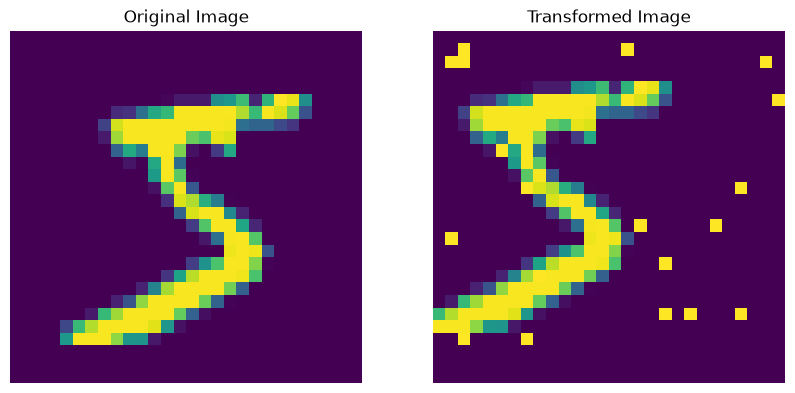

In [2]:
test_i = 0
test_img = mnist_data.data[0].unsqueeze(0)

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(test_img[0])
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(prepare_images(test_img)[0])
ax[1].set_title("Transformed Image")
ax[1].axis("off")
plt.show()

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device,", device)

Using device, cuda


##### Listing 10.2/10.3 - Relational module

Will use curiosity mechanism from "Self-Supervised Exploration via Disagreement" Pathek et al 2019.

In [ ]:
class RelationalModule(torch.nn.Module):
    def __init__(self):
        super(RelationalModule, self).__init__()
        self.ch_in = 1
        self.conv1_ch = 16  # A
        self.conv2_ch = 20  # dim `F` in paper
        self.conv3_ch = 24
        self.conv4_ch = 30
        self.H = 28  # B
        self.W = 28
        self.node_size = 36  # C, dim `E`, desired entity embedding size
        self.lin_hid = 100
        self.out_dim = 10
        self.sp_coord_dim = 2
        self.N = int(16**2)  # D

        self.conv1 = nn.Conv2d(self.ch_in, self.conv1_ch, kernel_size=(4, 4))
        self.conv2 = nn.Conv2d(self.conv1_ch, self.conv2_ch, kernel_size=(4, 4))
        self.conv3 = nn.Conv2d(self.conv2_ch, self.conv3_ch, kernel_size=(4, 4))
        self.conv4 = nn.Conv2d(self.conv3_ch, self.conv4_ch, kernel_size=(4, 4))

        self.proj_shape = (self.conv4_ch + self.sp_coord_dim, self.node_size)  # E
        self.k_proj = nn.Linear(*self.proj_shape)
        self.q_proj = nn.Linear(*self.proj_shape)
        self.v_proj = nn.Linear(*self.proj_shape)

        self.norm_shape = (self.N, self.node_size)
        self.k_norm = nn.LayerNorm(self.norm_shape, elementwise_affine=True)  # F
        self.q_norm = nn.LayerNorm(self.norm_shape, elementwise_affine=True)
        self.v_norm = nn.LayerNorm(self.norm_shape, elementwise_affine=True)

        self.linear1 = nn.Linear(self.node_size, self.node_size)
        self.norm1 = nn.LayerNorm([self.N, self.node_size], elementwise_affine=False)
        self.linear2 = nn.Linear(self.node_size, self.out_dim)

    def forward(self, x):
        N, Cin, H, W = x.shape
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = x.squeeze()
        x = torch.relu(x)
        x = self.conv3(x)
        x = torch.relu(x)
        x = self.conv4(x)
        x = torch.relu(x)

        _, _, cH, cW = x.shape
        xcoords = torch.arange(cW, device=device).repeat(cH, 1).float() / cW  # G
        ycoords = (
            torch.arange(cH, device=device).repeat(cW, 1).transpose(1, 0).float() / cH
        )
        spatial_coords = torch.stack([xcoords, ycoords], dim=0)
        spatial_coords = spatial_coords.unsqueeze(dim=0)
        spatial_coords = spatial_coords.repeat(N, 1, 1, 1)
        x = torch.cat([x, spatial_coords], dim=1)
        x = x.permute(0, 2, 3, 1)
        x = x.flatten(1, 2)

        K = self.k_proj(x)  # H
        K = self.k_norm(K)

        Q = self.q_proj(x)
        Q = self.q_norm(Q)

        V = self.v_proj(x)
        V = self.v_norm(V)
        A = torch.einsum("bfe,bge->bfg", Q, K)  # I
        A = A / np.sqrt(self.node_size)
        A = torch.nn.functional.softmax(A, dim=2)
        with torch.no_grad():
            self.att_map = A.clone()
        E = torch.einsum("bfc,bcd->bfd", A, V)  # J
        E = self.linear1(E)
        E = torch.relu(E)
        E = self.norm1(E)
        E = E.max(dim=1)[0]
        y = self.linear2(E)
        y = torch.nn.functional.log_softmax(y, dim=1)
        return y

##### Listing 10.4 - MNIST training loop

In [5]:
agent = RelationalModule().to(device)  # A
epochs = 1000
batch_size = 300
lr = 1e-3
opt = torch.optim.Adam(params=agent.parameters(), lr=lr)
lossfn = nn.NLLLoss()
losses, acc = [], []
for i in range(epochs):
    opt.zero_grad()
    batch_ids = np.random.randint(0, 60000, size=batch_size)  # B
    xt = mnist_data.data[batch_ids].detach()
    xt = prepare_images(xt, rot=30).unsqueeze(dim=1).to(device)  # C
    yt = mnist_data.targets[batch_ids].detach().to(device)
    pred = agent(xt)
    pred_labels = torch.argmax(pred, dim=1)  # D
    acc_ = 100.0 * (pred_labels == yt).sum() / batch_size  # E
    correct = torch.zeros(batch_size, 10)
    rows = torch.arange(batch_size).long()
    correct[tuple([rows, yt.detach().long()])] = 1.0
    loss = lossfn(pred, yt)
    loss.backward()
    opt.step()

    acc.append(acc_.cpu())
    losses.append(loss.detach().cpu().numpy())

losses = np.array(losses)
acc = np.array(acc)
acc[-1]

np.float32(97.333336)

Text(0.5, 1.0, 'Accuracy %')

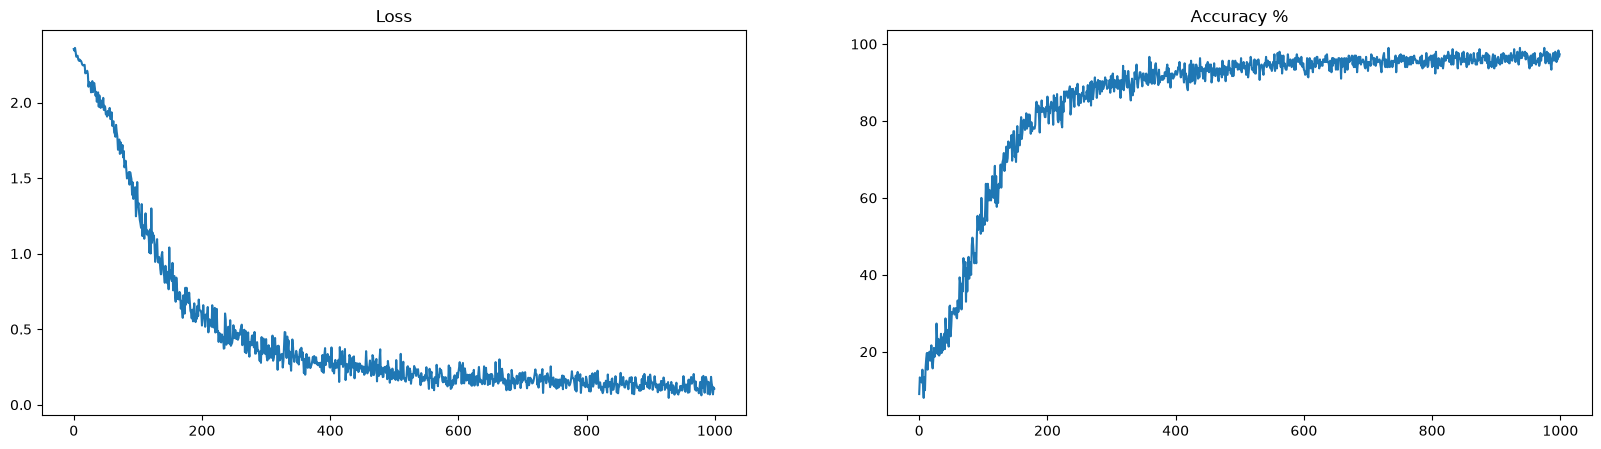

In [6]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(20, 5)
ax[0].plot(losses)
ax[0].set_title("Loss")
ax[1].plot(acc)
ax[1].set_title("Accuracy %")

##### Listing 10.5 - MNIST test accuracy

In [7]:
def test_acc(model, batch_size=500):
    acc = 0.0
    batch_ids = np.random.randint(0, 10000, size=batch_size)
    xt = mnist_test.data[batch_ids].detach()
    xt = prepare_images(xt, maxtrans=6, rot=30, noise=10).unsqueeze(dim=1).to(device)
    yt = mnist_test.targets[batch_ids].detach().to(device)
    preds = model(xt)
    pred_ind = torch.argmax(preds.detach(), dim=1)
    acc = (pred_ind == yt).sum().float() / batch_size
    return acc, xt, yt


acc2, xt2, yt2 = test_acc(agent)
print(acc2)

tensor(0.9480, device='cuda:0')


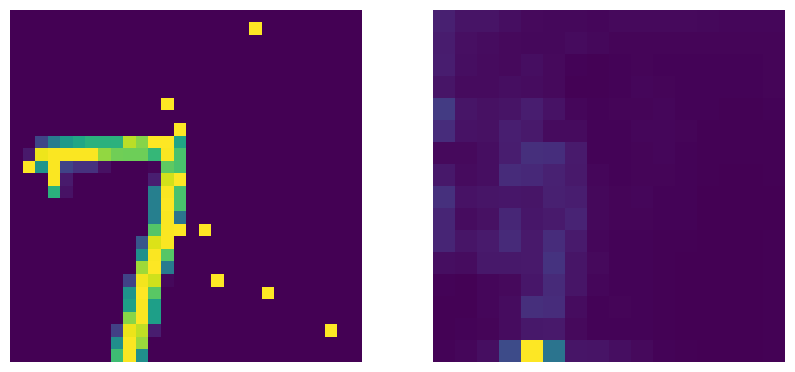

In [8]:
test_i = 0

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(xt2[test_i].cpu().view(28, 28))
ax[0].axis("off")
ax[1].imshow(agent.att_map[test_i].max(dim=0)[0].cpu().view(16, 16))
ax[1].axis("off")
plt.show()

##### Listing 10.6 - Convolutional neural network baseline for MNIST

In [9]:
class CNN(torch.nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=(4, 4))  # A
        self.conv2 = nn.Conv2d(10, 16, kernel_size=(4, 4))
        self.conv3 = nn.Conv2d(16, 24, kernel_size=(4, 4))
        self.conv4 = nn.Conv2d(24, 32, kernel_size=(4, 4))
        self.maxpool1 = nn.MaxPool2d(kernel_size=(2, 2))  # B
        self.conv5 = nn.Conv2d(32, 64, kernel_size=(4, 4))
        self.lin1 = nn.Linear(256, 128)
        self.out = nn.Linear(128, 10)  # C

    def forward(self, x):
        x = self.conv1(x)
        x = nn.functional.relu(x)
        x = self.conv2(x)
        x = nn.functional.relu(x)
        x = self.maxpool1(x)
        x = self.conv3(x)
        x = nn.functional.relu(x)
        x = self.conv4(x)
        x = nn.functional.relu(x)
        x = self.conv5(x)
        x = nn.functional.relu(x)
        x = x.flatten(start_dim=1)
        x = self.lin1(x)
        x = nn.functional.relu(x)
        x = self.out(x)
        x = nn.functional.log_softmax(x, dim=1)  # D
        return x

##### Listing 10.7 - Multi-head relational module

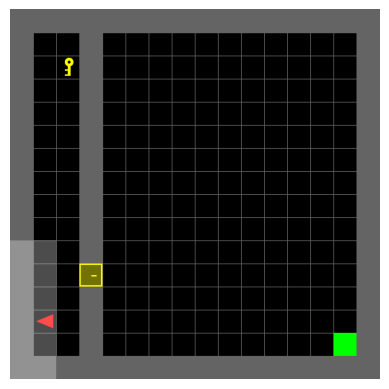

In [10]:
import gymnasium as gym
from minigrid.wrappers import ImgObsWrapper

env = ImgObsWrapper(gym.make("MiniGrid-DoorKey-16x16-v0", render_mode="rgb_array"))
env.reset()
plt.axis("off")
plt.imshow(env.render())

In [11]:
from einops import rearrange

x = torch.randn(5, 7, 7, 3)
# torch.Size([5, 3, 7, 7])
print(rearrange(x, "batch h w c -> batch c h w").shape)


x = torch.randn(5, 49, 3)
# torch.Size([5, 7, 7, 3])
print(rearrange(x, "batch (h w) c -> batch h w c", h=7).shape)

torch.Size([5, 3, 7, 7])
torch.Size([5, 7, 7, 3])


In [ ]:
class MultiHeadRelationalModule(torch.nn.Module):
    def __init__(self):
        super(MultiHeadRelationalModule, self).__init__()
        self.conv1_ch = 16
        self.conv2_ch = 20  # dim `F` in paper
        self.conv3_ch = 24
        self.conv4_ch = 30
        self.H = 28
        self.W = 28
        self.node_size = 64  # dim `E`, desired entity embedding size
        self.lin_hid = 100
        self.out_dim = 5
        self.ch_in = 3
        self.sp_coord_dim = 2
        self.N = int(7**2)
        self.n_heads = 3

        self.conv1 = nn.Conv2d(
            self.ch_in, self.conv1_ch, kernel_size=(1, 1), padding=0
        )  # A
        self.conv2 = nn.Conv2d(
            self.conv1_ch, self.conv2_ch, kernel_size=(1, 1), padding=0
        )
        self.proj_shape = (
            self.conv2_ch + self.sp_coord_dim,
            self.n_heads * self.node_size,
        )
        self.k_proj = nn.Linear(*self.proj_shape)
        self.q_proj = nn.Linear(*self.proj_shape)
        self.v_proj = nn.Linear(*self.proj_shape)

        self.k_lin = nn.Linear(self.node_size, self.N)  # B
        self.q_lin = nn.Linear(self.node_size, self.N)
        self.a_lin = nn.Linear(self.N, self.N)

        self.node_shape = (self.n_heads, self.N, self.node_size)
        self.k_norm = nn.LayerNorm(self.node_shape, elementwise_affine=True)
        self.q_norm = nn.LayerNorm(self.node_shape, elementwise_affine=True)
        self.v_norm = nn.LayerNorm(self.node_shape, elementwise_affine=True)

        self.linear1 = nn.Linear(self.n_heads * self.node_size, self.node_size)
        self.norm1 = nn.LayerNorm([self.N, self.node_size], elementwise_affine=False)
        self.linear2 = nn.Linear(self.node_size, self.out_dim)

    def forward(self, x):
        """
        `x` is a tensor (Batch_Size, C_{in}, Depth=1, Ht, Wt)
        """
        N, Cin, H, W = x.shape
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)
        with torch.no_grad():
            self.conv_map = x.clone()  # C
        _, _, cH, cW = x.shape
        xcoords = torch.arange(cW).repeat(cH, 1).float() / cW
        ycoords = torch.arange(cH).repeat(cW, 1).transpose(1, 0).float() / cH
        spatial_coords = torch.stack([xcoords, ycoords], dim=0)
        spatial_coords = spatial_coords.unsqueeze(dim=0)
        spatial_coords = spatial_coords.repeat(N, 1, 1, 1)
        x = torch.cat([x, spatial_coords], dim=1)
        x = x.permute(0, 2, 3, 1)
        x = x.flatten(1, 2)

        K = rearrange(self.k_proj(x), "b n (head d) -> b head n d", head=self.n_heads)
        K = self.k_norm(K)

        Q = rearrange(self.q_proj(x), "b n (head d) -> b head n d", head=self.n_heads)
        Q = self.q_norm(Q)

        V = rearrange(self.v_proj(x), "b n (head d) -> b head n d", head=self.n_heads)
        V = self.v_norm(V)
        A = torch.nn.functional.elu(self.q_lin(Q) + self.k_lin(K))  # D
        A = self.a_lin(A)
        A = torch.nn.functional.softmax(A, dim=3)
        with torch.no_grad():
            self.att_map = A.clone()  # E
        E = torch.einsum("bhfc,bhcd->bhfd", A, V)  # F
        E = rearrange(E, "b head n d -> b n (head d)")
        E = self.linear1(E)
        E = torch.relu(E)
        E = self.norm1(E)
        E = E.max(dim=1)[0]
        y = self.linear2(E)
        y = torch.nn.functional.elu(y)
        return y

##### Listing 10.8 - Preprocessing functions

In [ ]:
def prepare_state(x):  # A
    """
    Takes raw RGB numpy state from env and downsamples to 36x66
    and converts to torch tensor of dim 3x11x6 and normalizes values to 0-1
    """
    ns = torch.from_numpy(x).float().permute(2, 0, 1).unsqueeze(dim=0)  #
    maxv = ns.flatten().max()
    ns = ns / maxv
    return ns


def get_minibatch(replay, size):  # B
    """
    Returns a random subset of experiences from the experience replay memory
    """
    batch_ids = np.random.randint(0, len(replay), size)
    batch = [replay[x] for x in batch_ids]  # list of tuples
    state_batch = torch.cat(
        [s for (s, a, r, s2, d) in batch],
    )
    action_batch = torch.Tensor([a for (s, a, r, s2, d) in batch]).long()
    reward_batch = torch.Tensor([r for (s, a, r, s2, d) in batch])
    state2_batch = torch.cat([s2 for (s, a, r, s2, d) in batch], dim=0)
    done_batch = torch.Tensor([d for (s, a, r, s2, d) in batch])
    return state_batch, action_batch, reward_batch, state2_batch, done_batch


def get_qtarget_ddqn(qvals, r, df, done):  # C
    """
    `qvals`: q value batch Nx7
    `r`: reward batch Nx1
    `df`: discount factor, scalar float
    """
    targets = r + (1 - done) * df * qvals
    return targets

##### Listing 10.9 - Loss function and updating the replay

In [ ]:
def lossfn(pred, targets, actions):  # A
    """
    Computes q-value loss
    """
    q_values = pred.gather(dim=1, index=actions.unsqueeze(dim=1)).squeeze()
    loss = torch.mean(
        torch.pow(
            targets.detach() - q_values,
            2,
        ),
        dim=0,
    )
    return loss


def update_replay(replay, exp):  # B
    r = exp[2]
    N = 1
    if r > 0:
        N = 50
    for _ in range(N):
        replay.append(exp)
    return replay


action_map = {  # C
    0: 0,
    1: 1,
    2: 2,
    3: 3,
    4: 5,
}

for action in env.unwrapped.actions:
    print(f"Actions.{action.name:<8}: {action.value}")

Actions.left    : 0
Actions.right   : 1
Actions.forward : 2
Actions.pickup  : 3
Actions.drop    : 4
Actions.toggle  : 5
Actions.done    : 6


##### Listing 10.10 - The main training loop

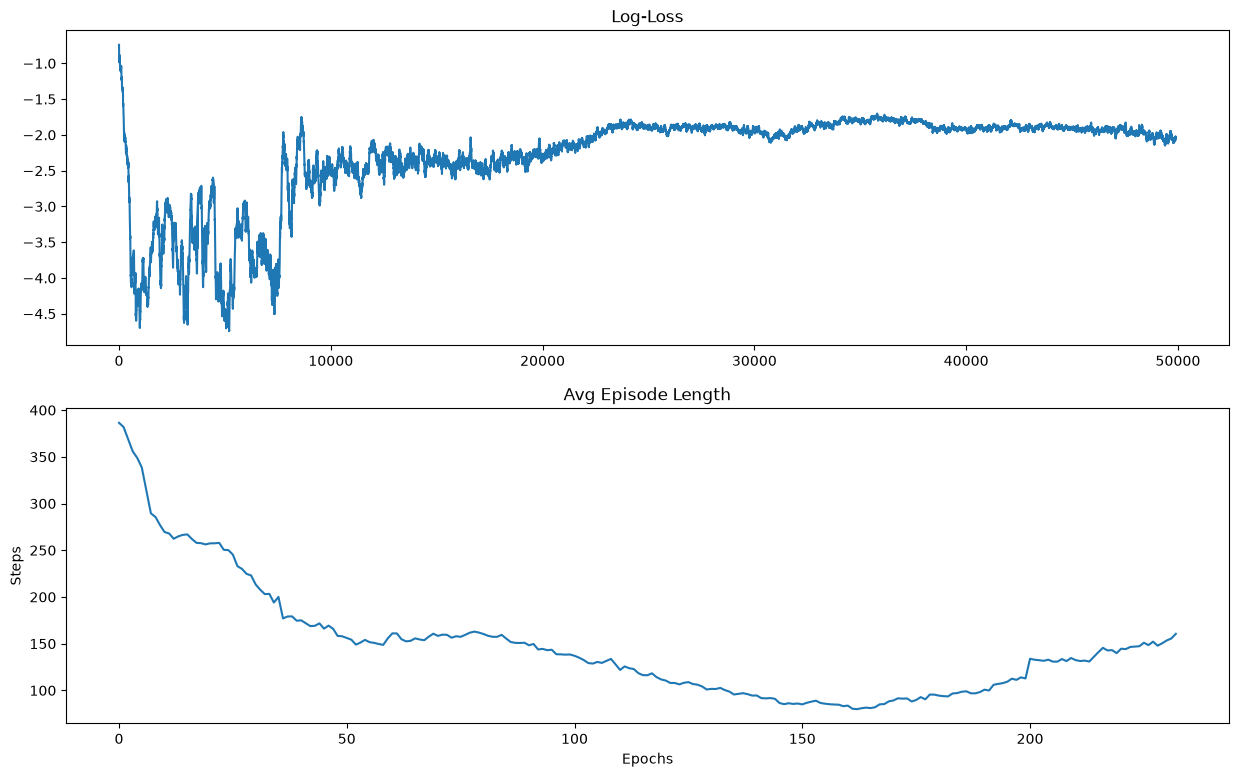

In [ ]:
from collections import deque

env = ImgObsWrapper(gym.make("MiniGrid-DoorKey-5x5-v0", render_mode="rgb_array"))  # A
state = prepare_state(env.reset()[0])
GWagent = MultiHeadRelationalModule()  # B
Tnet = MultiHeadRelationalModule()  # C
maxsteps = 400  # D
env.max_steps = maxsteps
env.env.max_steps = maxsteps

epochs = 50000
replay_size = 9000
batch_size = 50
lr = 0.0005
gamma = 0.99
replay = deque(maxlen=replay_size)  # E
opt = torch.optim.Adam(params=GWagent.parameters(), lr=lr)
eps = 0.5
update_freq = 100

losses = []
ep_lens = []
ep_len = 0

for i in range(epochs):
    if np.random.rand() < eps:  # F
        action = int(torch.randint(0, 5, size=(1,)).squeeze())
    else:
        pred = GWagent(state)  # get q-values
        action = int(torch.argmax(pred).detach().numpy())
    action_d = action_map[action]
    state2, reward, done, _, info = env.step(action_d)
    reward = -0.01 if reward == 0 else reward  # G
    state2 = prepare_state(state2)
    exp = (state, action, reward, state2, done)

    replay = update_replay(replay, exp)
    if done:
        ep_lens.append(ep_len)
        state = prepare_state(env.reset()[0])
        ep_len = 0
    else:
        state = state2
        ep_len += 1
    if len(replay) > batch_size:
        # begin batch training
        opt.zero_grad()

        state_batch, action_batch, reward_batch, state2_batch, done_batch = (
            get_minibatch(replay, batch_size)
        )

        q_pred = GWagent(state_batch).cpu()
        astar = torch.argmax(q_pred, dim=1)
        qs = Tnet(state2_batch).gather(dim=1, index=astar.unsqueeze(dim=1)).squeeze()

        targets = get_qtarget_ddqn(
            qs.detach(), reward_batch.detach(), gamma, done_batch
        )

        loss = lossfn(q_pred, targets.detach(), action_batch)
        loss.backward()
        losses.append(loss.detach().numpy())
        torch.nn.utils.clip_grad_norm_(GWagent.parameters(), max_norm=1.0)  # H
        opt.step()
    if i % update_freq == 0:  # I
        Tnet.load_state_dict(GWagent.state_dict())

fig, ax = plt.subplots(2, 1)
fig.set_size_inches(15, 9)
ax[0].set_title("Log-Loss")
ax[0].plot(running_mean(np.log10(np.array(losses)), 50))
ax[1].set_title("Avg Episode Length")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Steps")
ax[1].plot(running_mean(np.array(ep_lens), 50))

tensor([[-0.3756, -0.3453, -0.3863, -0.3720, -0.3893]], grad_fn=<EluBackward0>)


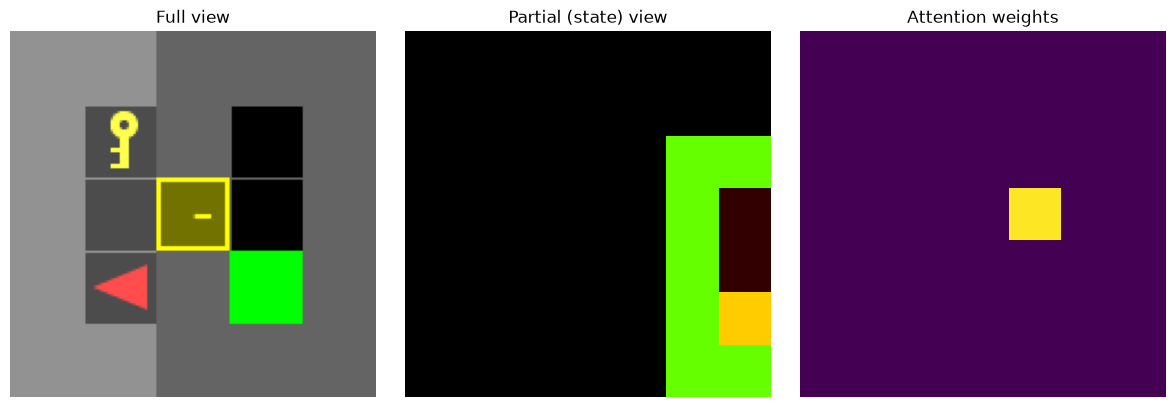

In [16]:
state_ = env.reset()
state = prepare_state(state_[0])
print(GWagent(state))

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(env.render())
ax[0].set_title("Full view")
ax[0].axis("off")

ax[1].imshow(state[0].permute(1, 2, 0).detach().numpy())
ax[1].set_title("Partial (state) view")
ax[1].axis("off")

head, node = 2, 26
ax[2].imshow(GWagent.att_map[0][head][node].view(7, 7))
ax[2].set_title("Attention weights")
ax[2].axis("off")

plt.tight_layout()
plt.show()

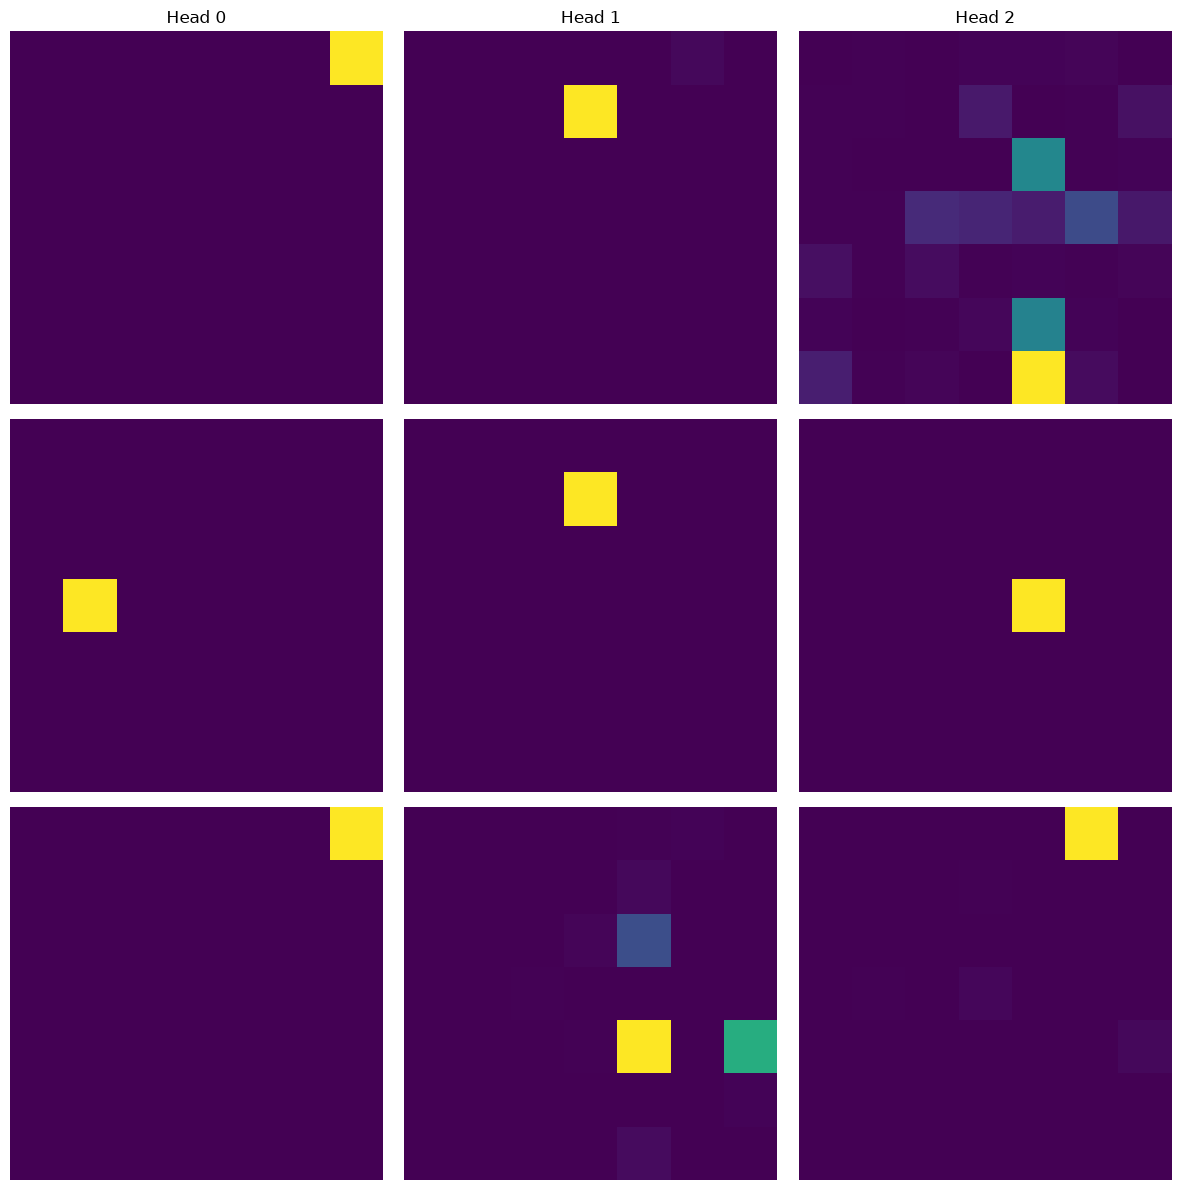

In [23]:
fig, ax = plt.subplots(3, 3, figsize=(12, 12))

for hi in range(3):
    ax[0, hi].set_title(f"Head {hi}")
    for node_j, node in enumerate([19, 26, 40]):
        ax[node_j, hi].imshow(GWagent.att_map[0][hi][node].view(7, 7))
        ax[node_j, hi].axis("off")

plt.tight_layout()
plt.show()